#Generate Dummy Data (Jangan Running)

In [ ]:
# ================================================================
# GENERATE 100 DATA DUMMY — SPK BEASISWA UNGGULAN
# Struktur folder:
#   /content/drive/MyDrive/SPK_Beasiswa/
#   ├── data_pendaftar.csv          ← data utama 100 pendaftar
#   ├── administrasi/
#   │   └── (simulasi file dokumen per pendaftar)
#   ├── penilaian_dm1_esai.csv      ← nilai 10 asesor DM1
#   ├── penilaian_dm2_rencana.csv   ← nilai 10 asesor DM2
#   └── penilaian_dm3_wawancara.csv ← nilai 10 asesor DM3
# ================================================================

import os
import numpy as np
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# ----------------------------------------------------------------
# Buat struktur folder
# ----------------------------------------------------------------
BASE_DIR  = '/content/drive/MyDrive/SPK_Beasiswa'
ADM_DIR   = f'{BASE_DIR}/administrasi'
NILAI_DIR = f'{BASE_DIR}/penilaian'

for folder in [BASE_DIR, ADM_DIR, NILAI_DIR]:
    os.makedirs(folder, exist_ok=True)
    print(f'✅ Folder siap: {folder}')


# ================================================================
# GENERATE DATA PENDAFTAR (100 orang)
# ================================================================
np.random.seed(99)
N = 100

nama_depan = [
    'Andi','Budi','Citra','Dian','Eko','Fani','Gilang','Hana','Ivan','Jeni',
    'Kiki','Lina','Mario','Nina','Oscar','Putri','Qori','Raka','Sari','Toni',
    'Umar','Vina','Wahyu','Xena','Yudi','Zahra','Adit','Bella','Candra','Dewi',
    'Elsa','Fajar','Gita','Hendra','Indah','Joko','Kartika','Lukman','Mira','Nanda',
    'Okta','Pandu','Rina','Surya','Tika','Ulfa','Vicky','Wulan','Yoga','Zulfa'
]
nama_belakang = [
    'Pratama','Santoso','Dewi','Rahayu','Nugroho','Kusuma','Arya','Putri','Saputra','Lestari',
    'Wijaya','Sari','Hidayat','Permata','Setiawan','Wibowo','Arifin','Subekti','Hartono','Prabowo',
    'Utama','Anwar','Firmansyah','Amalia','Hakim','Nuraini','Siregar','Kurniawan','Maharani','Susanto'
]

def random_nama():
    return f"{np.random.choice(nama_depan)} {np.random.choice(nama_belakang)}"

jenis_tes_list = ['ITP', 'PTE', 'IBT', 'IELTS']
batas_bahasa   = {'ITP': 550, 'PTE': 58, 'IBT': 80, 'IELTS': 6.5}

rows = []
for i in range(1, N + 1):
    bid = f'BU-{i:03d}'

    # Usia & status kuliah
    sedang_kuliah = bool(np.random.choice([True, False], p=[0.6, 0.4]))
    batas_usia    = 33 if sedang_kuliah else 32
    # ~15% sengaja melebihi batas agar ada yang tidak lolos
    if np.random.rand() < 0.15:
        usia = np.random.randint(batas_usia + 1, batas_usia + 5)
    else:
        usia = np.random.randint(21, batas_usia + 1)

    # IPK — ~12% di bawah 3.00
    if np.random.rand() < 0.12:
        ipk = round(np.random.uniform(2.50, 2.99), 2)
    else:
        ipk = round(np.random.uniform(3.00, 4.00), 2)

    # UKBI — ~10% di bawah 578
    if np.random.rand() < 0.10:
        skor_ukbi = np.random.randint(500, 578)
    else:
        skor_ukbi = np.random.randint(578, 701)

    # Bahasa asing — ~10% di bawah batas
    jenis_tes = np.random.choice(jenis_tes_list)
    batas_min = batas_bahasa[jenis_tes]
    if np.random.rand() < 0.10:
        if jenis_tes == 'IELTS':
            skor_tes = round(np.random.uniform(4.0, 6.4), 1)
        else:
            skor_tes = np.random.randint(int(batas_min * 0.8), batas_min)
    else:
        if jenis_tes == 'IELTS':
            skor_tes = round(np.random.uniform(6.5, 9.0), 1)
        else:
            skor_tes = np.random.randint(batas_min, int(batas_min * 1.3))

    # Kelengkapan dokumen — ~8% ada dokumen bermasalah
    def doc_status(missing_prob=0.05, invalid_prob=0.03):
        r = np.random.rand()
        if r < missing_prob:
            return None, False      # tidak ada
        elif r < missing_prob + invalid_prob:
            return f'file.pdf', False  # ada tapi tidak valid
        else:
            return f'file.pdf', True   # ada dan valid

    rek_file,  rek_valid  = doc_status(0.05, 0.03)
    loa_file,  loa_valid  = doc_status(0.05, 0.03)
    rs_file,   rs_valid   = doc_status(0.04, 0.03)
    esai_file, esai_valid = doc_status(0.04, 0.03)

    rows.append({
        'id':                    bid,
        'nama':                  random_nama(),
        'usia':                  usia,
        'sedang_kuliah':         sedang_kuliah,
        'ipk':                   ipk,
        'skor_ukbi':             skor_ukbi,
        'jenis_tes_bahasa':      jenis_tes,
        'skor_tes_bahasa':       skor_tes,
        'file_rekomendasi':      rek_file,
        'rekomendasi_valid':     rek_valid,
        'file_loa_surat_aktif':  loa_file,
        'loa_valid':             loa_valid,
        'file_rencana_studi':    rs_file,
        'rencana_studi_valid':   rs_valid,
        'file_esai':             esai_file,
        'esai_valid':            esai_valid,
    })

df_pendaftar = pd.DataFrame(rows)
df_pendaftar.to_csv(f'{BASE_DIR}/data_pendaftar.csv', index=False)
print(f'\n✅ data_pendaftar.csv tersimpan ({len(df_pendaftar)} baris)')
print(df_pendaftar.head(5).to_string())


# ================================================================
# GENERATE DATA PENILAIAN ASESOR per DM
# Format: baris = kandidat_id, kolom = Asesor_1 s/d Asesor_10
# Satu file per kriteria per DM
# ================================================================

KRITERIA = {
    'DM1_Esai': {
        'label': 'DM1_Esai',
        'kriteria': ['Relevansi_Topik', 'Kedalaman_Analisis',
                     'Kualitas_Penulisan', 'Orisinalitas_Ide']
    },
    'DM2_RencanaStudi': {
        'label': 'DM2_RencanaStudi',
        'kriteria': ['Kejelasan_Tujuan', 'Kelayakan_Timeline',
                     'Relevansi_Bidang', 'Dampak_Rencana']
    },
    'DM3_Wawancara': {
        'label': 'DM3_Wawancara',
        'kriteria': ['Motivasi_Komitmen', 'Kemampuan_Komunikasi',
                     'Pemahaman_Bidang', 'Leadership_Potential']
    }
}

# Kandidat yang akan dinilai = semua 100 orang dulu
# (nanti saat SPK dijalankan, yang tidak lolos admin akan difilter)
semua_ids = df_pendaftar['id'].tolist()
N_ASESOR  = 10

for dm_key, dm_val in KRITERIA.items():
    dm_dir = f'{NILAI_DIR}/{dm_val["label"]}'
    os.makedirs(dm_dir, exist_ok=True)

    for kriteria_nama in dm_val['kriteria']:
        # Setiap file: baris = kandidat, kolom = Asesor_1..Asesor_10
        data_nilai = np.random.uniform(1, 10, (len(semua_ids), N_ASESOR))
        df_nilai = pd.DataFrame(
            data_nilai,
            index=semua_ids,
            columns=[f'Asesor_{j+1}' for j in range(N_ASESOR)]
        )
        df_nilai.index.name = 'id'
        df_nilai = df_nilai.round(2)

        path_file = f'{dm_dir}/{kriteria_nama}.csv'
        df_nilai.to_csv(path_file)

    print(f'✅ {dm_val["label"]}: {len(dm_val["kriteria"])} file kriteria tersimpan → {dm_dir}')


# ================================================================
# TAMPILKAN STRUKTUR FOLDER FINAL
# ================================================================
print('\n📁 Struktur folder di Google Drive:')
for root, dirs, files in os.walk(BASE_DIR):
    level = root.replace(BASE_DIR, '').count(os.sep)
    indent = '    ' * level
    print(f'{indent}📂 {os.path.basename(root)}/')
    sub_indent = '    ' * (level + 1)
    for f in files:
        size = os.path.getsize(os.path.join(root, f))
        print(f'{sub_indent}📄 {f}  ({size:,} bytes)')

print('\n✅ Semua data dummy siap. Lanjut ke kode SPK utama.')

Mounted at /content/drive
✅ Folder siap: /content/drive/MyDrive/SPK_Beasiswa
✅ Folder siap: /content/drive/MyDrive/SPK_Beasiswa/administrasi
✅ Folder siap: /content/drive/MyDrive/SPK_Beasiswa/penilaian

✅ data_pendaftar.csv tersimpan (100 baris)
       id            nama  usia  sedang_kuliah   ipk  skor_ukbi jenis_tes_bahasa  skor_tes_bahasa file_rekomendasi  rekomendasi_valid file_loa_surat_aktif  loa_valid file_rencana_studi  rencana_studi_valid file_esai  esai_valid
0  BU-001   Citra Pratama    30          False  3.70        601              IBT             97.0         file.pdf               True                 None      False           file.pdf                 True  file.pdf        True
1  BU-002    Joko Prabowo    30           True  3.33        640              PTE             70.0         file.pdf               True             file.pdf       True           file.pdf                 True  file.pdf        True
2  BU-003    Yudi Saputra    34          False  3.29        544       

✅ 100 data pendaftar berhasil dibaca dari Drive


,ID,Nama,Status,Jumlah Masalah,Masalah
0,BU-001,Citra Pratama,❌ TIDAK LOLOS,1,Surat LoA/Surat Aktif tidak ada
1,BU-002,Joko Prabowo,✅ LOLOS,0,-
2,BU-003,Yudi Saputra,❌ TIDAK LOLOS,4,Usia 34 tahun melebihi batas 32 tahun | UKBI 5...
3,BU-004,Joko Permata,❌ TIDAK LOLOS,1,Format esai tidak sesuai — perlu verifikasi ma...
4,BU-005,Rina Kurniawan,✅ LOLOS,0,-
...,...,...,...,...,...
95,BU-096,Joko Nuraini,✅ LOLOS,0,-
96,BU-097,Yoga Dewi,✅ LOLOS,0,-
97,BU-098,Citra Firmansyah,✅ LOLOS,0,-
98,BU-099,Lina Putri,✅ LOLOS,0,-


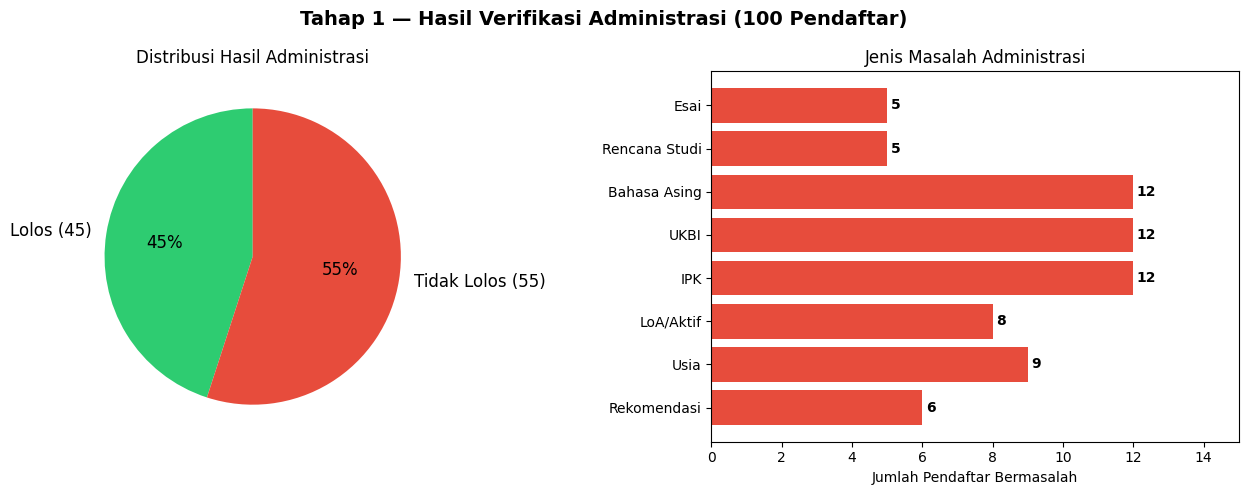

✅ Matriks DM 1 — Esai dibaca: (45, 4)
✅ Matriks DM 2 — Rencana Studi dibaca: (45, 4)
✅ Matriks DM 3 — Wawancara dibaca: (45, 4)


,Relevansi_Topik,Kedalaman_Analisis,Kualitas_Penulisan,Orisinalitas_Ide
BU-002,4.007,6.289,6.362,6.112
BU-005,5.911,4.743,5.388,5.814
BU-007,5.526,5.752,5.090,5.803
BU-008,6.726,4.015,5.764,6.405
BU-012,6.399,5.763,5.706,4.304


,Nama,Skor TOPSIS,Ranking
1,Kartika Dewi,0.7145,1
2,Ivan Amalia,0.6842,2
3,Ulfa Arifin,0.6755,3
4,Citra Arifin,0.6267,4
5,Oscar Nugroho,0.6210,5
6,Yoga Kurniawan,0.6187,6
7,Sari Rahayu,0.6096,7
8,Ulfa Maharani,0.5930,8
9,Yoga Prabowo,0.5778,9
10,Eko Santoso,0.5755,10


,Nama,Skor TOPSIS,Ranking
1,Ulfa Arifin,0.6791,1
2,Toni Putri,0.6763,2
3,Sari Rahayu,0.6552,3
4,Kartika Dewi,0.6518,4
5,Bella Susanto,0.6384,5
6,Kartika Permata,0.6296,6
7,Rina Anwar,0.6219,7
8,Yoga Kurniawan,0.6116,8
9,Umar Nuraini,0.6025,9
10,Oscar Nuraini,0.5709,10


,Nama,Skor TOPSIS,Ranking
1,Joko Kusuma,0.6672,1
2,Umar Nuraini,0.6660,2
3,Indah Dewi,0.6566,3
4,Nina Permata,0.6303,4
5,Toni Putri,0.6265,5
6,Kartika Putri,0.6259,6
7,Citra Arifin,0.6222,7
8,Lukman Hartono,0.6199,8
9,Wahyu Subekti,0.6153,9
10,Yoga Dewi,0.6111,10


,Nama,Rank Esai,Rank Rencana Studi,Rank Wawancara,Total Poin Borda,Ranking Final
1,Kartika Dewi,1,4,12,118,1
2,Citra Arifin,4,13,7,111,2
3,Sari Rahayu,7,3,15,110,3
4,Nina Wibowo,16,14,13,92,4
5,Bella Susanto,24,5,17,89,5
6,Eko Santoso,10,12,24,89,5
7,Ulfa Arifin,3,1,43,88,7
8,Rina Anwar,18,7,22,88,7
9,Toni Putri,41,2,5,87,9
10,Yoga Kurniawan,6,8,36,85,10


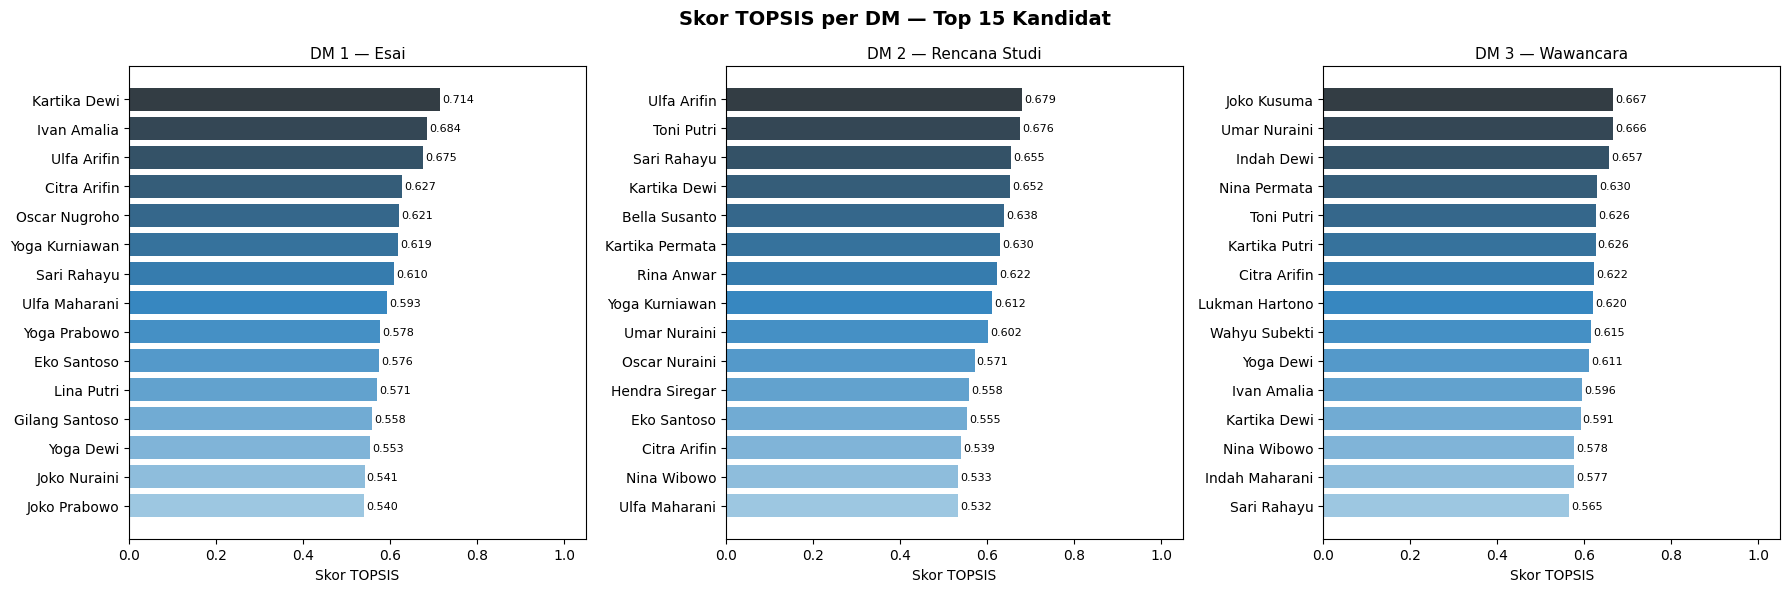

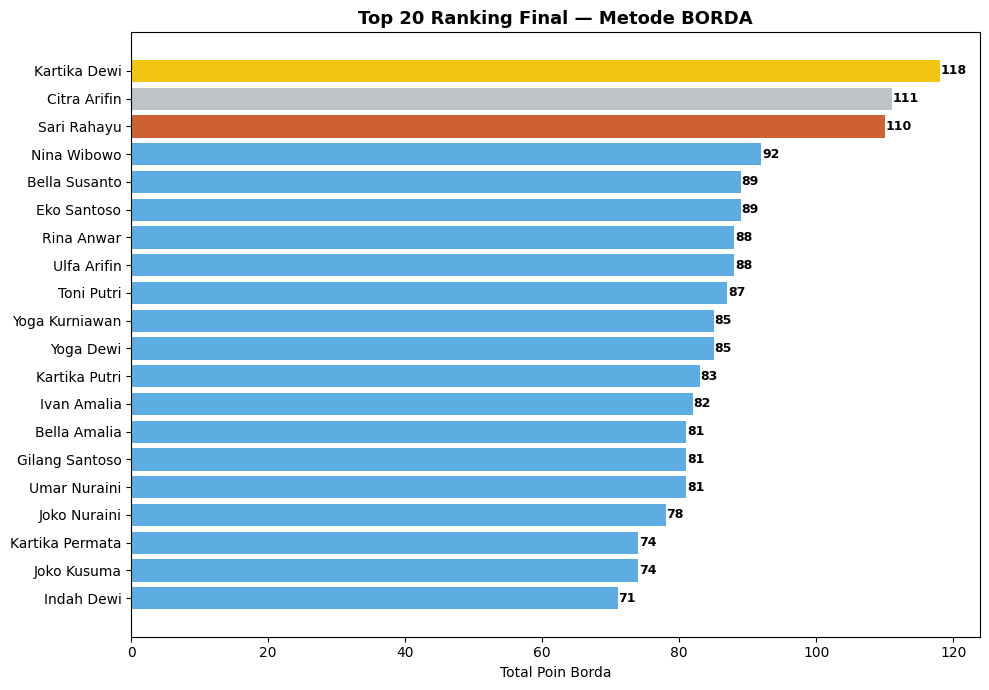

,Nama,Rank Esai,Rank Rencana Studi,Rank Wawancara,Total Poin Borda,Ranking Final
1,Kartika Dewi,1,4,12,118,1
2,Citra Arifin,4,13,7,111,2
3,Sari Rahayu,7,3,15,110,3
4,Nina Wibowo,16,14,13,92,4
5,Bella Susanto,24,5,17,89,5
6,Eko Santoso,10,12,24,89,5
7,Ulfa Arifin,3,1,43,88,7
8,Rina Anwar,18,7,22,88,7
9,Toni Putri,41,2,5,87,9
10,Yoga Kurniawan,6,8,36,85,10


,Nama,Rank Esai,Rank Rencana Studi,Rank Wawancara,Total Poin Borda,Ranking Final
12,Kartika Putri,26,20,6,83,12
13,Ivan Amalia,2,40,11,82,13
14,Bella Amalia,17,21,16,81,14
15,Gilang Santoso,12,17,25,81,14
16,Umar Nuraini,43,9,2,81,14



✅ Selesai.


In [ ]:
# ================================================================
# SPK BEASISWA UNGGULAN — Baca dari Google Drive
# (Jalankan setelah cell generate data di atas)
# ================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display, HTML

BASE_DIR  = '/content/drive/MyDrive/SPK_Beasiswa'
NILAI_DIR = f'{BASE_DIR}/penilaian'

def header(text, level=1):
    colors = {1: '#1a3c6e', 2: '#2e6da4', 3: '#4a90d9'}
    sizes  = {1: '22px', 2: '18px', 3: '15px'}
    display(HTML(
        f'<h{level} style="color:{colors[level]};font-size:{sizes[level]};'
        f'border-bottom:2px solid {colors[level]};padding-bottom:4px;margin-top:20px">'
        f'{text}</h{level}>'
    ))

def alert(text, kind='info'):
    cfg = {
        'info':    ('#d1ecf1','#0c5460','ℹ️'),
        'success': ('#d4edda','#155724','✅'),
        'danger':  ('#f8d7da','#721c24','❌'),
        'warning': ('#fff3cd','#856404','⚠️'),
    }
    bg, fg, icon = cfg[kind]
    display(HTML(
        f'<div style="background:{bg};color:{fg};padding:10px 14px;'
        f'border-radius:6px;margin:4px 0"><b>{icon} {text}</b></div>'
    ))

# ----------------------------------------------------------------
# Baca data pendaftar dari Drive
# ----------------------------------------------------------------
df_pendaftar = pd.read_csv(f'{BASE_DIR}/data_pendaftar.csv')
pendaftar_raw = df_pendaftar.to_dict('records')
print(f'✅ {len(pendaftar_raw)} data pendaftar berhasil dibaca dari Drive')

# ================================================================
# TAHAP 1 — VERIFIKASI ADMINISTRASI
# ================================================================

BATAS_BAHASA      = {'ITP': 550, 'PTE': 58, 'IBT': 80, 'IELTS': 6.5}
BATAS_IPK         = 3.00
BATAS_UKBI        = 578
BATAS_USIA_UMUM   = 32
BATAS_USIA_KULIAH = 33

def cek_bahasa(jenis, skor):
    if jenis not in BATAS_BAHASA:
        return False, f'Jenis tes tidak dikenal: {jenis}'
    minimal = BATAS_BAHASA[jenis]
    lolos = skor >= minimal
    return lolos, (f'{jenis} {skor} >= {minimal} OK' if lolos
                   else f'{jenis} {skor} < {minimal} (minimal {minimal})')

def verifikasi_administrasi(kandidat):
    flags = []

    # 1. Rekomendasi
    ada_rek = pd.notna(kandidat.get('file_rekomendasi')) and bool(kandidat.get('file_rekomendasi'))
    if not ada_rek:
        flags.append('Surat rekomendasi tidak ada')
    elif not bool(kandidat.get('rekomendasi_valid', False)):
        flags.append('Format surat rekomendasi tidak valid — perlu verifikasi manual')

    # 2. Usia
    usia = kandidat.get('usia', 99)
    sedang_kuliah = bool(kandidat.get('sedang_kuliah', False))
    batas_usia = BATAS_USIA_KULIAH if sedang_kuliah else BATAS_USIA_UMUM
    if usia > batas_usia:
        flags.append(f'Usia {usia} tahun melebihi batas {batas_usia} tahun')

    # 3. LoA / Surat Aktif
    ada_loa = pd.notna(kandidat.get('file_loa_surat_aktif')) and bool(kandidat.get('file_loa_surat_aktif'))
    if not ada_loa:
        flags.append('Surat LoA/Surat Aktif tidak ada')
    elif not bool(kandidat.get('loa_valid', False)):
        flags.append('Surat LoA/Aktif tidak valid — perlu verifikasi manual')

    # 4. IPK
    ipk = float(kandidat.get('ipk', 0))
    if ipk < BATAS_IPK:
        flags.append(f'IPK {ipk} di bawah minimal {BATAS_IPK}')

    # 5. UKBI
    ukbi = int(kandidat.get('skor_ukbi', 0))
    if ukbi < BATAS_UKBI:
        flags.append(f'UKBI {ukbi} di bawah minimal Unggul ({BATAS_UKBI})')

    # 6. Bahasa Asing
    jenis_tes = str(kandidat.get('jenis_tes_bahasa', ''))
    skor_tes  = float(kandidat.get('skor_tes_bahasa', 0))
    bahasa_ok, bahasa_pesan = cek_bahasa(jenis_tes, skor_tes)
    if not bahasa_ok:
        flags.append(f'Bahasa asing: {bahasa_pesan}')

    # 7. Rencana Studi
    ada_rs = pd.notna(kandidat.get('file_rencana_studi')) and bool(kandidat.get('file_rencana_studi'))
    if not ada_rs:
        flags.append('File rencana studi tidak ada')
    elif not bool(kandidat.get('rencana_studi_valid', False)):
        flags.append('Format rencana studi tidak sesuai — perlu verifikasi manual')

    # 8. Esai
    ada_esai = pd.notna(kandidat.get('file_esai')) and bool(kandidat.get('file_esai'))
    if not ada_esai:
        flags.append('File esai tidak ada')
    elif not bool(kandidat.get('esai_valid', False)):
        flags.append('Format esai tidak sesuai — perlu verifikasi manual')

    return {
        'id':                    kandidat['id'],
        'nama':                  kandidat['nama'],
        'flags':                 flags,
        'lolos_administrasi':    len(flags) == 0,
        'perlu_verifikasi_manual': len(flags) > 0
    }

header("TAHAP 1 — Verifikasi Administrasi (100 Pendaftar)", level=1)

hasil_admin = []
lolos_admin = []

for p in pendaftar_raw:
    res = verifikasi_administrasi(p)
    hasil_admin.append(res)
    if res['lolos_administrasi']:
        lolos_admin.append(p)

# Tampilkan ringkasan (tidak ditampilkan satu per satu karena 100 orang)
df_admin_summary = pd.DataFrame([{
    'ID':     r['id'],
    'Nama':   r['nama'],
    'Status': '✅ LOLOS' if r['lolos_administrasi'] else '❌ TIDAK LOLOS',
    'Jumlah Masalah': len(r['flags']),
    'Masalah': ' | '.join(r['flags']) if r['flags'] else '-'
} for r in hasil_admin])

header("Ringkasan Administrasi", level=2)
display(df_admin_summary)

alert(f'Total Pendaftar: {len(pendaftar_raw)} orang', 'info')
alert(f'Lolos Administrasi: {len(lolos_admin)} orang', 'success')
alert(f'Tidak Lolos: {len(pendaftar_raw) - len(lolos_admin)} orang', 'danger')

# Visualisasi administrasi
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Tahap 1 — Hasil Verifikasi Administrasi (100 Pendaftar)',
             fontsize=14, fontweight='bold')

jml_lolos = len(lolos_admin)
jml_tidak = len(pendaftar_raw) - jml_lolos
axes[0].pie(
    [jml_lolos, jml_tidak],
    labels=[f'Lolos ({jml_lolos})', f'Tidak Lolos ({jml_tidak})'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.0f%%', startangle=90,
    textprops={'fontsize': 12}
)
axes[0].set_title('Distribusi Hasil Administrasi')

kategori_flags = {
    'Rekomendasi': 0, 'Usia': 0, 'LoA/Aktif': 0,
    'IPK': 0, 'UKBI': 0, 'Bahasa Asing': 0,
    'Rencana Studi': 0, 'Esai': 0
}
mapping_flag = {
    'rekomendasi': 'Rekomendasi', 'usia': 'Usia', 'loa': 'LoA/Aktif',
    'ipk': 'IPK', 'ukbi': 'UKBI', 'bahasa': 'Bahasa Asing',
    'rencana studi': 'Rencana Studi', 'esai': 'Esai'
}
for r in hasil_admin:
    for f in r['flags']:
        for kw, kat in mapping_flag.items():
            if kw in f.lower():
                kategori_flags[kat] += 1
                break

cats = list(kategori_flags.keys())
vals = list(kategori_flags.values())
bars = axes[1].barh(cats, vals,
                    color=['#e74c3c' if v > 0 else '#bdc3c7' for v in vals])
axes[1].set_xlabel('Jumlah Pendaftar Bermasalah')
axes[1].set_title('Jenis Masalah Administrasi')
axes[1].set_xlim(0, max(vals) + 3)
for bar, val in zip(bars, vals):
    if val > 0:
        axes[1].text(val + 0.1, bar.get_y() + bar.get_height() / 2,
                     str(val), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Simpan laporan administrasi ke Drive
df_admin_summary.to_csv(f'{BASE_DIR}/laporan_administrasi.csv', index=False)
alert('laporan_administrasi.csv tersimpan ke Drive', 'success')


# ================================================================
# TAHAP 2 — PENILAIAN SUBSTANSI
# ================================================================

header("TAHAP 2 — Penilaian Substansi (DSS + GDSS)", level=1)

KRITERIA = {
    'DM1_Esai': {
        'label': 'DM 1 — Esai',
        'folder': 'DM1_Esai',
        'kriteria': [
            {'nama': 'Relevansi_Topik',       'bobot': 0.25, 'tipe': 'benefit'},
            {'nama': 'Kedalaman_Analisis',     'bobot': 0.30, 'tipe': 'benefit'},
            {'nama': 'Kualitas_Penulisan',     'bobot': 0.25, 'tipe': 'benefit'},
            {'nama': 'Orisinalitas_Ide',       'bobot': 0.20, 'tipe': 'benefit'},
        ]
    },
    'DM2_RencanaStudi': {
        'label': 'DM 2 — Rencana Studi',
        'folder': 'DM2_RencanaStudi',
        'kriteria': [
            {'nama': 'Kejelasan_Tujuan',       'bobot': 0.30, 'tipe': 'benefit'},
            {'nama': 'Kelayakan_Timeline',     'bobot': 0.25, 'tipe': 'benefit'},
            {'nama': 'Relevansi_Bidang',       'bobot': 0.25, 'tipe': 'benefit'},
            {'nama': 'Dampak_Rencana',         'bobot': 0.20, 'tipe': 'benefit'},
        ]
    },
    'DM3_Wawancara': {
        'label': 'DM 3 — Wawancara',
        'folder': 'DM3_Wawancara',
        'kriteria': [
            {'nama': 'Motivasi_Komitmen',      'bobot': 0.30, 'tipe': 'benefit'},
            {'nama': 'Kemampuan_Komunikasi',   'bobot': 0.25, 'tipe': 'benefit'},
            {'nama': 'Pemahaman_Bidang',       'bobot': 0.25, 'tipe': 'benefit'},
            {'nama': 'Leadership_Potential',   'bobot': 0.20, 'tipe': 'benefit'},
        ]
    }
}

ids_lolos = [p['id']   for p in lolos_admin]
nama_map  = {p['id']: p['nama'] for p in pendaftar_raw}

# ----------------------------------------------------------------
# Baca matriks penilaian dari Drive
# Rata-ratakan 10 asesor → 1 nilai per kandidat per kriteria
# ----------------------------------------------------------------
def baca_matriks_dm(dm_val, kandidat_ids):
    dm_dir = f'{NILAI_DIR}/{dm_val["folder"]}'
    df_rata = pd.DataFrame(index=kandidat_ids)
    for k in dm_val['kriteria']:
        path = f'{dm_dir}/{k["nama"]}.csv'
        df_asesor = pd.read_csv(path, index_col='id')
        # Filter hanya kandidat yang lolos admin
        df_asesor = df_asesor.loc[df_asesor.index.isin(kandidat_ids)]
        # Rata-rata 10 asesor
        df_rata[k['nama']] = df_asesor.mean(axis=1)
    return df_rata

matriks_dm = {}
for dm_key, dm_val in KRITERIA.items():
    matriks_dm[dm_key] = baca_matriks_dm(dm_val, ids_lolos)
    print(f'✅ Matriks {dm_val["label"]} dibaca: {matriks_dm[dm_key].shape}')

header("Contoh Matriks DM1 — Esai (5 kandidat pertama)", level=3)
display(matriks_dm['DM1_Esai'].head().round(3))

# ----------------------------------------------------------------
# TOPSIS
# ----------------------------------------------------------------
def topsis(matriks, kriteria_list):
    X = matriks.values.astype(float)
    n, m = X.shape
    norm = np.sqrt((X ** 2).sum(axis=0))
    norm[norm == 0] = 1e-10
    R = X / norm
    bobot = np.array([k['bobot'] for k in kriteria_list])
    V = R * bobot
    A_plus  = np.array([V[:, j].max() if kriteria_list[j]['tipe'] == 'benefit'
                        else V[:, j].min() for j in range(m)])
    A_minus = np.array([V[:, j].min() if kriteria_list[j]['tipe'] == 'benefit'
                        else V[:, j].max() for j in range(m)])
    D_plus  = np.sqrt(((V - A_plus)  ** 2).sum(axis=1))
    D_minus = np.sqrt(((V - A_minus) ** 2).sum(axis=1))
    denom = D_plus + D_minus
    denom[denom == 0] = 1e-10
    Ci = D_minus / denom
    return pd.Series(Ci, index=matriks.index, name='Skor_TOPSIS')

skor_topsis    = {}
ranking_topsis = {}

header("Hasil TOPSIS per DM (Top 10)", level=2)
for dm_key, dm_val in KRITERIA.items():
    skor = topsis(matriks_dm[dm_key], dm_val['kriteria'])
    rank = skor.rank(ascending=False, method='min').astype(int)
    skor_topsis[dm_key]    = skor
    ranking_topsis[dm_key] = rank

    df_show = pd.DataFrame({
        'Nama':        [nama_map[i] for i in skor.index],
        'Skor TOPSIS': skor.round(4),
        'Ranking':     rank
    }).sort_values('Ranking').head(10)
    df_show.index = range(1, len(df_show) + 1)

    header(f'{dm_val["label"]} — Top 10', level=3)
    display(df_show)

# ----------------------------------------------------------------
# BORDA
# ----------------------------------------------------------------
def borda_count(ranking_dict, kandidat_ids):
    n = len(kandidat_ids)
    scores = pd.Series(0.0, index=kandidat_ids)
    for dm_key, ranking in ranking_dict.items():
        for kid in kandidat_ids:
            scores[kid] += (n - ranking[kid])
    return scores

borda_scores  = borda_count(ranking_topsis, ids_lolos)
ranking_final = borda_scores.rank(ascending=False, method='min').astype(int)

df_final = pd.DataFrame({'Nama': [nama_map[i] for i in borda_scores.index]})
for dm_key, dm_val in KRITERIA.items():
    label_k = 'Rank ' + dm_val['label'].split('—')[1].strip()
    df_final[label_k] = [ranking_topsis[dm_key][kid] for kid in borda_scores.index]
df_final['Total Poin Borda'] = borda_scores.values.astype(int)
df_final['Ranking Final']    = ranking_final.values
df_final = df_final.sort_values('Ranking Final')
df_final.index = range(1, len(df_final) + 1)

header("Ranking Final — BORDA (Top 20)", level=2)
display(df_final.head(20))

# ----------------------------------------------------------------
# Visualisasi TOPSIS
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Skor TOPSIS per DM — Top 15 Kandidat', fontsize=14, fontweight='bold')

for idx, (dm_key, dm_val) in enumerate(KRITERIA.items()):
    skor = skor_topsis[dm_key]
    top15_ids  = skor.sort_values(ascending=False).head(15).index
    top15_nama = [nama_map[i][:15] for i in top15_ids]
    top15_vals = skor[top15_ids].values
    palette    = sns.color_palette('Blues_d', 15)
    bars = axes[idx].barh(top15_nama[::-1], top15_vals[::-1], color=palette)
    axes[idx].set_title(dm_val['label'], fontsize=11)
    axes[idx].set_xlabel('Skor TOPSIS')
    axes[idx].set_xlim(0, 1.05)
    for bar, val in zip(bars, top15_vals[::-1]):
        axes[idx].text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                       f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

# Visualisasi Borda Top 20
fig2, ax2 = plt.subplots(figsize=(10, 7))
top20_ids  = borda_scores.sort_values(ascending=False).head(20).index
top20_nama = [nama_map[i][:20] for i in top20_ids]
top20_vals = borda_scores[top20_ids].values
gold = ['#f1c40f','#bdc3c7','#cd6133'] + ['#5dade2'] * 17

bars2 = ax2.barh(top20_nama[::-1], top20_vals[::-1], color=gold[::-1])
ax2.set_title('Top 20 Ranking Final — Metode BORDA', fontsize=13, fontweight='bold')
ax2.set_xlabel('Total Poin Borda')
for bar, val in zip(bars2, top20_vals[::-1]):
    ax2.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
             str(int(val)), va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

# ================================================================
# LAPORAN AKHIR
# ================================================================

KUOTA_BEASISWA = 10  # ubah sesuai kebutuhan

header("LAPORAN AKHIR — SPK BEASISWA UNGGULAN", level=1)
alert(f'Total Pendaftar: {len(pendaftar_raw)} orang', 'info')
alert(f'Lolos Administrasi: {len(lolos_admin)} orang', 'info')
alert(f'Kuota Beasiswa: {KUOTA_BEASISWA} orang', 'info')

penerima = df_final[df_final['Ranking Final'] <= KUOTA_BEASISWA]
cadangan  = df_final[(df_final['Ranking Final'] > KUOTA_BEASISWA) &
                     (df_final['Ranking Final'] <= KUOTA_BEASISWA + 5)]

header(f"Penerima Beasiswa Direkomendasikan (Top {KUOTA_BEASISWA})", level=2)
display(penerima)

header("Daftar Cadangan (5 berikutnya)", level=2)
display(cadangan)

# Simpan semua laporan ke Drive
df_final.to_csv(f'{BASE_DIR}/laporan_substansi_final.csv')
df_topsis = pd.DataFrame({
    dm_val['label']: skor_topsis[dm_key]
    for dm_key, dm_val in KRITERIA.items()
})
df_topsis.insert(0, 'Nama', [nama_map[i] for i in df_topsis.index])
df_topsis.to_csv(f'{BASE_DIR}/skor_topsis_per_dm.csv')

alert('Semua laporan tersimpan ke Google Drive:', 'success')
alert(f'{BASE_DIR}/laporan_administrasi.csv', 'info')
alert(f'{BASE_DIR}/laporan_substansi_final.csv', 'info')
alert(f'{BASE_DIR}/skor_topsis_per_dm.csv', 'info')
print("\n✅ Selesai.")

#Codingan


Ringkasan: 3 dari 7 pendaftar lolos administrasi


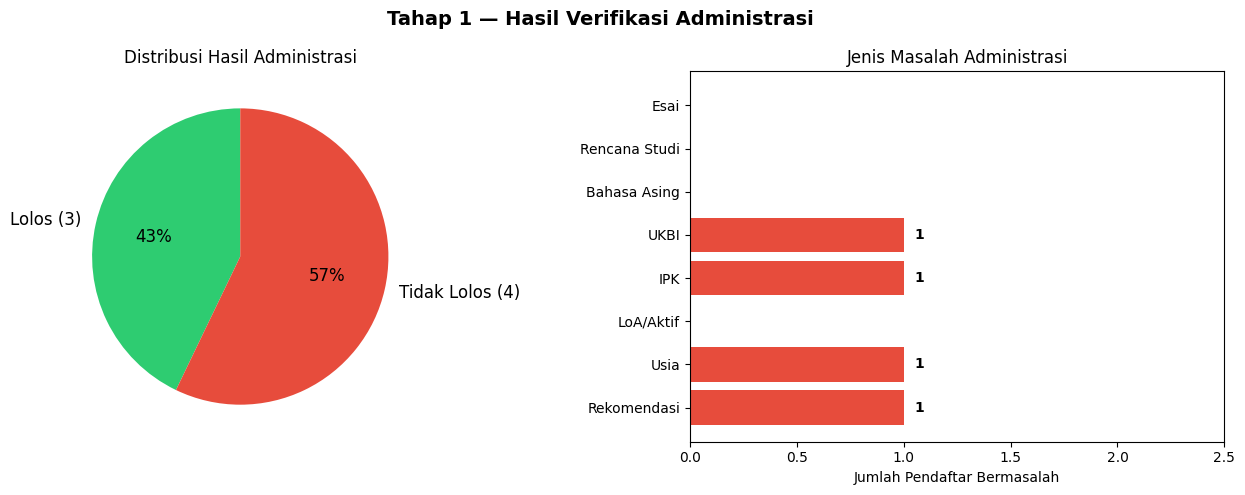

,Relevansi Topik,Kedalaman Analisis,Kualitas Penulisan,Orisinalitas Ide
BU-001,4.574,4.733,5.813,5.054
BU-004,5.513,5.186,3.967,6.553
BU-006,5.531,5.736,5.331,5.537


,Nama,Skor TOPSIS,Ranking
1,Fani Kusuma,0.7033,1
2,Andi Pratama,0.5010,2
3,Dian Rahayu,0.4343,3


,Nama,Skor TOPSIS,Ranking
1,Andi Pratama,0.7263,1
2,Dian Rahayu,0.6471,2
3,Fani Kusuma,0.1511,3


,Nama,Skor TOPSIS,Ranking
1,Andi Pratama,1.0000,1
2,Dian Rahayu,0.3638,2
3,Fani Kusuma,0.3503,3


,Nama,Rank Esai,Rank Rencana Studi,Rank Wawancara,Total Poin Borda,Ranking Final
1,Andi Pratama,2,1,1,5,1
2,Dian Rahayu,3,2,2,2,2
3,Fani Kusuma,1,3,3,2,2


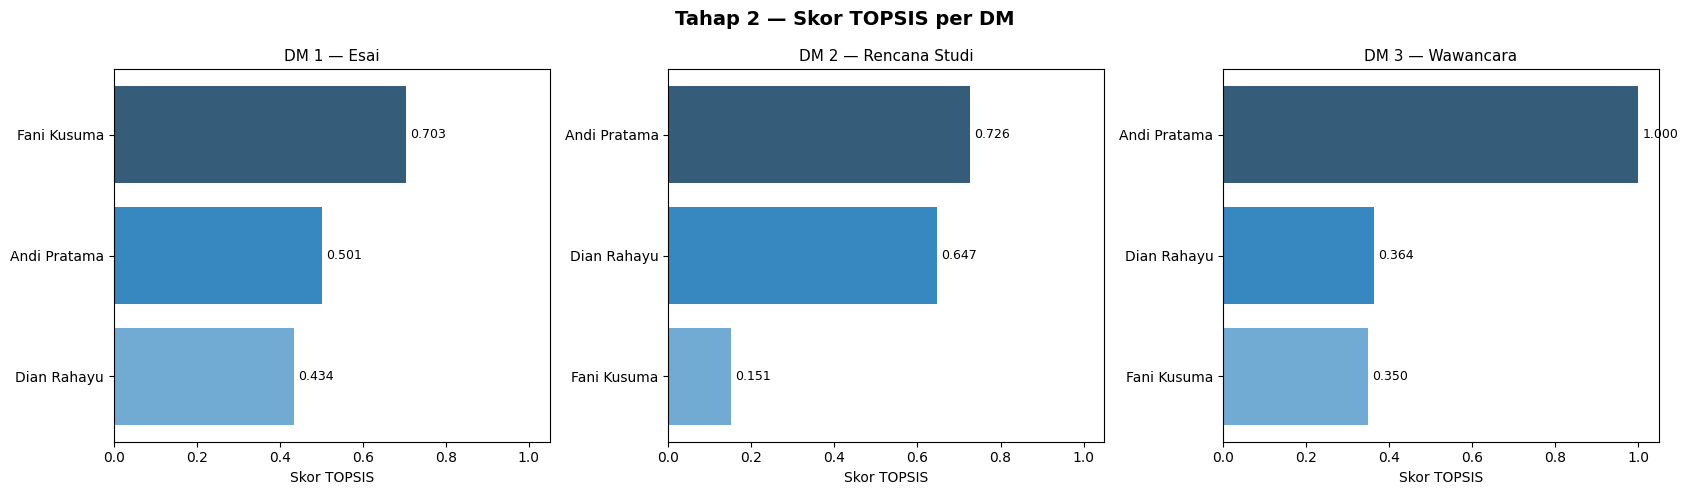

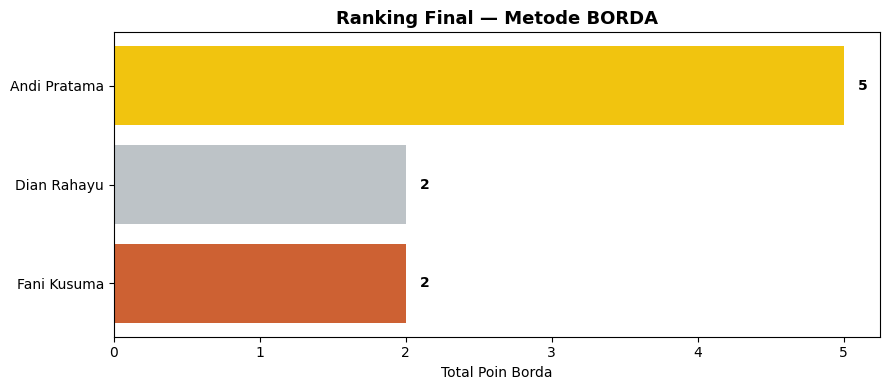

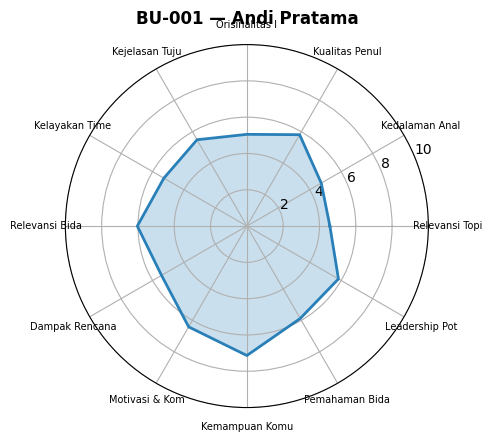

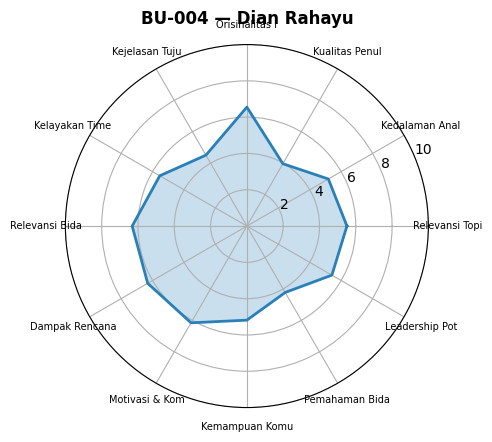

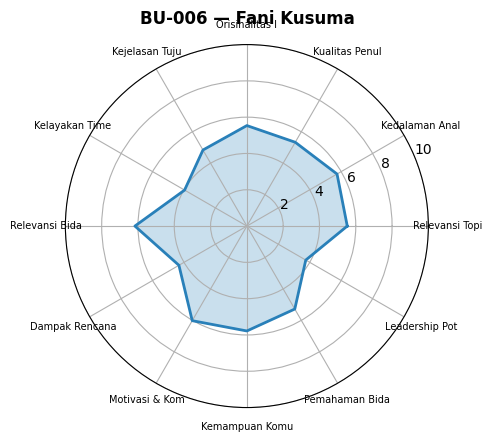

,Nama,Rank Esai,Rank Rencana Studi,Rank Wawancara,Total Poin Borda,Ranking Final
1,Andi Pratama,2,1,1,5,1
2,Dian Rahayu,3,2,2,2,2
3,Fani Kusuma,1,3,3,2,2


,Nama,Rank Esai,Rank Rencana Studi,Rank Wawancara,Total Poin Borda,Ranking Final



Selesai.


In [ ]:
# ================================================================
# SISTEM PENDUKUNG KEPUTUSAN — BEASISWA UNGGULAN
# Tahap 1: Verifikasi Administrasi
# Tahap 2: Penilaian Substansi (TOPSIS + BORDA)
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display, HTML

def header(text, level=1):
    colors = {1: '#1a3c6e', 2: '#2e6da4', 3: '#4a90d9'}
    sizes  = {1: '22px', 2: '18px', 3: '15px'}
    display(HTML(
        f'<h{level} style="color:{colors[level]};font-size:{sizes[level]};'
        f'border-bottom:2px solid {colors[level]};padding-bottom:4px;margin-top:20px">'
        f'{text}</h{level}>'
    ))

def alert(text, kind='info'):
    cfg = {
        'info':    ('#d1ecf1', '#0c5460', 'ℹ️'),
        'success': ('#d4edda', '#155724', '✅'),
        'danger':  ('#f8d7da', '#721c24', '❌'),
        'warning': ('#fff3cd', '#856404', '⚠️'),
    }
    bg, fg, icon = cfg[kind]
    display(HTML(
        f'<div style="background:{bg};color:{fg};padding:10px 14px;'
        f'border-radius:6px;margin:4px 0"><b>{icon} {text}</b></div>'
    ))

# ================================================================
# BAGIAN 1 — TAHAP ADMINISTRASI
# ================================================================

BATAS_BAHASA        = {'ITP': 550, 'PTE': 58, 'IBT': 80, 'IELTS': 6.5}
BATAS_IPK           = 3.00
BATAS_UKBI          = 578
BATAS_USIA_UMUM     = 32
BATAS_USIA_KULIAH   = 33

def cek_bahasa(jenis, skor):
    if jenis not in BATAS_BAHASA:
        return False, f'Jenis tes tidak dikenal: {jenis}'
    minimal = BATAS_BAHASA[jenis]
    lolos = skor >= minimal
    return lolos, (f'{jenis} {skor} >= {minimal} OK' if lolos
                   else f'{jenis} {skor} < {minimal} (minimal {minimal})')

def verifikasi_administrasi(kandidat):
    hasil = {}
    flags = []

    # 1. Rekomendasi
    ada_rek = bool(kandidat.get('file_rekomendasi'))
    hasil['rekomendasi'] = {'ada': ada_rek, 'valid': kandidat.get('rekomendasi_valid', False)}
    if not ada_rek:
        flags.append('Surat rekomendasi tidak ada')
    elif not hasil['rekomendasi']['valid']:
        flags.append('Format surat rekomendasi tidak valid — perlu verifikasi manual')

    # 2. Usia
    usia = kandidat.get('usia', 99)
    sedang_kuliah = kandidat.get('sedang_kuliah', False)
    batas_usia = BATAS_USIA_KULIAH if sedang_kuliah else BATAS_USIA_UMUM
    usia_ok = usia <= batas_usia
    hasil['usia'] = {'nilai': usia, 'batas': batas_usia, 'lolos': usia_ok}
    if not usia_ok:
        flags.append(f'Usia {usia} tahun melebihi batas {batas_usia} tahun')

    # 3. LoA / Surat Aktif
    ada_loa = bool(kandidat.get('file_loa_surat_aktif'))
    hasil['loa_surat_aktif'] = {'ada': ada_loa, 'valid': kandidat.get('loa_valid', False)}
    if not ada_loa:
        flags.append('Surat LoA/Surat Aktif tidak ada')
    elif not hasil['loa_surat_aktif']['valid']:
        flags.append('Surat LoA/Aktif tidak valid — perlu verifikasi manual')

    # 4. IPK
    ipk = kandidat.get('ipk', 0.0)
    ipk_ok = ipk >= BATAS_IPK
    hasil['ipk'] = {'nilai': ipk, 'batas': BATAS_IPK, 'lolos': ipk_ok}
    if not ipk_ok:
        flags.append(f'IPK {ipk} di bawah minimal {BATAS_IPK}')

    # 5. UKBI
    ukbi = kandidat.get('skor_ukbi', 0)
    ukbi_ok = ukbi >= BATAS_UKBI
    hasil['ukbi'] = {'nilai': ukbi, 'batas': BATAS_UKBI, 'lolos': ukbi_ok}
    if not ukbi_ok:
        flags.append(f'UKBI {ukbi} di bawah minimal Unggul ({BATAS_UKBI})')

    # 6. Bahasa Asing
    jenis_tes = kandidat.get('jenis_tes_bahasa', '')
    skor_tes  = kandidat.get('skor_tes_bahasa', 0)
    bahasa_ok, bahasa_pesan = cek_bahasa(jenis_tes, skor_tes)
    hasil['bahasa_asing'] = {'jenis': jenis_tes, 'skor': skor_tes, 'lolos': bahasa_ok}
    if not bahasa_ok:
        flags.append(f'Bahasa asing: {bahasa_pesan}')

    # 7. Rencana Studi
    ada_rs = bool(kandidat.get('file_rencana_studi'))
    hasil['rencana_studi'] = {'ada': ada_rs, 'valid': kandidat.get('rencana_studi_valid', False)}
    if not ada_rs:
        flags.append('File rencana studi tidak ada')
    elif not hasil['rencana_studi']['valid']:
        flags.append('Format rencana studi tidak sesuai — perlu verifikasi manual')

    # 8. Esai
    ada_esai = bool(kandidat.get('file_esai'))
    hasil['esai'] = {'ada': ada_esai, 'valid': kandidat.get('esai_valid', False)}
    if not ada_esai:
        flags.append('File esai tidak ada')
    elif not hasil['esai']['valid']:
        flags.append('Format esai tidak sesuai — perlu verifikasi manual')

    hasil['flags']                   = flags
    hasil['lolos_administrasi']      = len(flags) == 0
    hasil['perlu_verifikasi_manual'] = len(flags) > 0
    return hasil

# ----------------------------------------------------------------
# DATA PENDAFTAR
# Ganti isi list ini dengan data nyata, atau baca dari Excel:
#   df = pd.read_excel('data_pendaftar.xlsx')
#   pendaftar_raw = df.to_dict('records')
# ----------------------------------------------------------------
pendaftar_raw = [
    {
        'id': 'BU-001', 'nama': 'Andi Pratama',
        'usia': 24, 'sedang_kuliah': True,
        'file_rekomendasi': 'rek.pdf',   'rekomendasi_valid': True,
        'file_loa_surat_aktif': 'loa.pdf', 'loa_valid': True,
        'ipk': 3.75, 'skor_ukbi': 610,
        'jenis_tes_bahasa': 'IELTS', 'skor_tes_bahasa': 7.0,
        'file_rencana_studi': 'rs.pdf',  'rencana_studi_valid': True,
        'file_esai': 'esai.pdf',         'esai_valid': True,
    },
    {
        'id': 'BU-002', 'nama': 'Budi Santoso',
        'usia': 28, 'sedang_kuliah': False,
        'file_rekomendasi': 'rek.pdf',   'rekomendasi_valid': True,
        'file_loa_surat_aktif': 'loa.pdf', 'loa_valid': True,
        'ipk': 2.95,   # di bawah 3.00
        'skor_ukbi': 590,
        'jenis_tes_bahasa': 'ITP', 'skor_tes_bahasa': 560,
        'file_rencana_studi': 'rs.pdf',  'rencana_studi_valid': True,
        'file_esai': 'esai.pdf',         'esai_valid': True,
    },
    {
        'id': 'BU-003', 'nama': 'Citra Dewi',
        'usia': 26, 'sedang_kuliah': True,
        'file_rekomendasi': None,        'rekomendasi_valid': False,  # tidak ada
        'file_loa_surat_aktif': 'loa.pdf', 'loa_valid': True,
        'ipk': 3.50, 'skor_ukbi': 600,
        'jenis_tes_bahasa': 'PTE', 'skor_tes_bahasa': 62,
        'file_rencana_studi': 'rs.pdf',  'rencana_studi_valid': True,
        'file_esai': 'esai.pdf',         'esai_valid': True,
    },
    {
        'id': 'BU-004', 'nama': 'Dian Rahayu',
        'usia': 30, 'sedang_kuliah': False,
        'file_rekomendasi': 'rek.pdf',   'rekomendasi_valid': True,
        'file_loa_surat_aktif': 'loa.pdf', 'loa_valid': True,
        'ipk': 3.80, 'skor_ukbi': 620,
        'jenis_tes_bahasa': 'IBT', 'skor_tes_bahasa': 90,
        'file_rencana_studi': 'rs.pdf',  'rencana_studi_valid': True,
        'file_esai': 'esai.pdf',         'esai_valid': True,
    },
    {
        'id': 'BU-005', 'nama': 'Eko Nugroho',
        'usia': 35, 'sedang_kuliah': False,  # usia melebihi batas
        'file_rekomendasi': 'rek.pdf',   'rekomendasi_valid': True,
        'file_loa_surat_aktif': 'loa.pdf', 'loa_valid': True,
        'ipk': 3.60, 'skor_ukbi': 595,
        'jenis_tes_bahasa': 'IELTS', 'skor_tes_bahasa': 7.5,
        'file_rencana_studi': 'rs.pdf',  'rencana_studi_valid': True,
        'file_esai': 'esai.pdf',         'esai_valid': True,
    },
    {
        'id': 'BU-006', 'nama': 'Fani Kusuma',
        'usia': 25, 'sedang_kuliah': True,
        'file_rekomendasi': 'rek.pdf',   'rekomendasi_valid': True,
        'file_loa_surat_aktif': 'loa.pdf', 'loa_valid': True,
        'ipk': 3.65, 'skor_ukbi': 580,
        'jenis_tes_bahasa': 'ITP', 'skor_tes_bahasa': 555,
        'file_rencana_studi': 'rs.pdf',  'rencana_studi_valid': True,
        'file_esai': 'esai.pdf',         'esai_valid': True,
    },
    {
        'id': 'BU-007', 'nama': 'Gilang Arya',
        'usia': 27, 'sedang_kuliah': False,
        'file_rekomendasi': 'rek.pdf',   'rekomendasi_valid': True,
        'file_loa_surat_aktif': 'loa.pdf', 'loa_valid': True,
        'ipk': 3.45,
        'skor_ukbi': 540,  # di bawah 578
        'jenis_tes_bahasa': 'IBT', 'skor_tes_bahasa': 82,
        'file_rencana_studi': 'rs.pdf',  'rencana_studi_valid': True,
        'file_esai': 'esai.pdf',         'esai_valid': True,
    },
]

# ----------------------------------------------------------------
# Jalankan verifikasi administrasi
# ----------------------------------------------------------------
header("TAHAP 1 — Verifikasi Administrasi", level=1)

hasil_admin = []
lolos_admin = []

for p in pendaftar_raw:
    res = verifikasi_administrasi(p)
    res['id']   = p['id']
    res['nama'] = p['nama']
    hasil_admin.append(res)
    if res['lolos_administrasi']:
        lolos_admin.append(p)

for r in hasil_admin:
    status = '✅ LOLOS' if r['lolos_administrasi'] else '❌ TIDAK LOLOS'
    display(HTML(
        f'<div style="margin-top:12px;font-weight:bold;font-size:14px">'
        f'{r["id"]} — {r["nama"]} &nbsp;&nbsp; {status}</div>'
    ))
    if r['flags']:
        for f in r['flags']:
            alert(f'🔴 {f}', 'danger')
    else:
        alert('Semua persyaratan administrasi terpenuhi', 'success')

print(f'\nRingkasan: {len(lolos_admin)} dari {len(pendaftar_raw)} pendaftar lolos administrasi')

# ----------------------------------------------------------------
# Visualisasi administrasi
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Tahap 1 — Hasil Verifikasi Administrasi', fontsize=14, fontweight='bold')

jml_lolos = len(lolos_admin)
jml_tidak = len(pendaftar_raw) - jml_lolos
axes[0].pie(
    [jml_lolos, jml_tidak],
    labels=[f'Lolos ({jml_lolos})', f'Tidak Lolos ({jml_tidak})'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.0f%%', startangle=90,
    textprops={'fontsize': 12}
)
axes[0].set_title('Distribusi Hasil Administrasi')

kategori_flags = {
    'Rekomendasi': 0, 'Usia': 0, 'LoA/Aktif': 0,
    'IPK': 0, 'UKBI': 0, 'Bahasa Asing': 0,
    'Rencana Studi': 0, 'Esai': 0
}
mapping_flag = {
    'rekomendasi': 'Rekomendasi', 'usia': 'Usia', 'loa': 'LoA/Aktif',
    'ipk': 'IPK', 'ukbi': 'UKBI', 'bahasa': 'Bahasa Asing',
    'rencana studi': 'Rencana Studi', 'esai': 'Esai'
}
for r in hasil_admin:
    for f in r['flags']:
        for kw, kat in mapping_flag.items():
            if kw in f.lower():
                kategori_flags[kat] += 1
                break

cats = list(kategori_flags.keys())
vals = list(kategori_flags.values())
colors_bar = ['#e74c3c' if v > 0 else '#bdc3c7' for v in vals]
bars = axes[1].barh(cats, vals, color=colors_bar)
axes[1].set_xlabel('Jumlah Pendaftar Bermasalah')
axes[1].set_title('Jenis Masalah Administrasi')
axes[1].set_xlim(0, max(vals) + 1.5)
for bar, val in zip(bars, vals):
    if val > 0:
        axes[1].text(val + 0.05, bar.get_y() + bar.get_height() / 2,
                     str(val), va='center', fontweight='bold')
plt.tight_layout()
plt.show()


# ================================================================
# BAGIAN 2 — TAHAP SUBSTANSI (DSS + GDSS)
# ================================================================

header("TAHAP 2 — Penilaian Substansi (DSS + GDSS)", level=1)

# ----------------------------------------------------------------
# Kriteria dan bobot per DM
# Ubah bobot sesuai kebijakan panitia (total harus = 1.0 per DM)
# ----------------------------------------------------------------
KRITERIA = {
    'DM1_Esai': {
        'label': 'DM 1 — Esai',
        'kriteria': [
            {'nama': 'Relevansi Topik',       'bobot': 0.25, 'tipe': 'benefit'},
            {'nama': 'Kedalaman Analisis',     'bobot': 0.30, 'tipe': 'benefit'},
            {'nama': 'Kualitas Penulisan',     'bobot': 0.25, 'tipe': 'benefit'},
            {'nama': 'Orisinalitas Ide',       'bobot': 0.20, 'tipe': 'benefit'},
        ]
    },
    'DM2_RencanaStudi': {
        'label': 'DM 2 — Rencana Studi',
        'kriteria': [
            {'nama': 'Kejelasan Tujuan',       'bobot': 0.30, 'tipe': 'benefit'},
            {'nama': 'Kelayakan Timeline',     'bobot': 0.25, 'tipe': 'benefit'},
            {'nama': 'Relevansi Bidang Studi', 'bobot': 0.25, 'tipe': 'benefit'},
            {'nama': 'Dampak Rencana',         'bobot': 0.20, 'tipe': 'benefit'},
        ]
    },
    'DM3_Wawancara': {
        'label': 'DM 3 — Wawancara',
        'kriteria': [
            {'nama': 'Motivasi & Komitmen',    'bobot': 0.30, 'tipe': 'benefit'},
            {'nama': 'Kemampuan Komunikasi',   'bobot': 0.25, 'tipe': 'benefit'},
            {'nama': 'Pemahaman Bidang',       'bobot': 0.25, 'tipe': 'benefit'},
            {'nama': 'Leadership Potential',   'bobot': 0.20, 'tipe': 'benefit'},
        ]
    }
}

ids_lolos = [p['id']   for p in lolos_admin]
nama_map  = {p['id']: p['nama'] for p in pendaftar_raw}

# ----------------------------------------------------------------
# Simulasi penilaian 10 asesor per DM → rata-rata = matriks keputusan
# Untuk data nyata, ganti dengan:
#   matriks_dm['DM1_Esai'] = pd.read_excel('nilai_dm1.xlsx', index_col='ID')
# ----------------------------------------------------------------
np.random.seed(42)

def simulasi_penilaian(kandidat_ids, kriteria_list, n_asesor=10):
    n_k = len(kandidat_ids)
    n_c = len(kriteria_list)
    skor_semua = np.random.uniform(1, 10, (n_asesor, n_k, n_c))
    rata = skor_semua.mean(axis=0)
    return pd.DataFrame(rata, index=kandidat_ids,
                        columns=[k['nama'] for k in kriteria_list])

matriks_dm = {}
for dm_key, dm_val in KRITERIA.items():
    matriks_dm[dm_key] = simulasi_penilaian(ids_lolos, dm_val['kriteria'])

header("Contoh Matriks Penilaian — DM1 Esai (rata-rata 10 asesor)", level=3)
display(matriks_dm['DM1_Esai'].round(3))

# ----------------------------------------------------------------
# TOPSIS
# ----------------------------------------------------------------
def topsis(matriks, kriteria_list):
    X = matriks.values.astype(float)
    n, m = X.shape

    # Normalisasi
    norm = np.sqrt((X ** 2).sum(axis=0))
    norm[norm == 0] = 1e-10
    R = X / norm

    # Pembobotan
    bobot = np.array([k['bobot'] for k in kriteria_list])
    V = R * bobot

    # Solusi ideal
    A_plus  = np.array([V[:, j].max() if kriteria_list[j]['tipe'] == 'benefit'
                        else V[:, j].min() for j in range(m)])
    A_minus = np.array([V[:, j].min() if kriteria_list[j]['tipe'] == 'benefit'
                        else V[:, j].max() for j in range(m)])

    # Jarak Euclidean
    D_plus  = np.sqrt(((V - A_plus)  ** 2).sum(axis=1))
    D_minus = np.sqrt(((V - A_minus) ** 2).sum(axis=1))

    # Skor preferensi
    denom = D_plus + D_minus
    denom[denom == 0] = 1e-10
    Ci = D_minus / denom

    return pd.Series(Ci, index=matriks.index, name='Skor_TOPSIS')

skor_topsis    = {}
ranking_topsis = {}

header("Hasil TOPSIS per DM", level=2)
for dm_key, dm_val in KRITERIA.items():
    skor = topsis(matriks_dm[dm_key], dm_val['kriteria'])
    rank = skor.rank(ascending=False, method='min').astype(int)
    skor_topsis[dm_key]    = skor
    ranking_topsis[dm_key] = rank

    df_show = pd.DataFrame({
        'Nama':        [nama_map[i] for i in skor.index],
        'Skor TOPSIS': skor.round(4),
        'Ranking':     rank
    }).sort_values('Ranking')
    df_show.index = range(1, len(df_show) + 1)

    header(dm_val['label'], level=3)
    display(df_show)

# ----------------------------------------------------------------
# BORDA
# ----------------------------------------------------------------
def borda_count(ranking_dict, kandidat_ids):
    n = len(kandidat_ids)
    scores = pd.Series(0.0, index=kandidat_ids)
    for dm_key, ranking in ranking_dict.items():
        for kid in kandidat_ids:
            scores[kid] += (n - ranking[kid])
    return scores

borda_scores  = borda_count(ranking_topsis, ids_lolos)
ranking_final = borda_scores.rank(ascending=False, method='min').astype(int)

header("Ranking Final — Metode BORDA", level=2)

df_final = pd.DataFrame({'Nama': [nama_map[i] for i in borda_scores.index]})
for dm_key, dm_val in KRITERIA.items():
    label_k = 'Rank ' + dm_val['label'].split('—')[1].strip()
    df_final[label_k] = [ranking_topsis[dm_key][kid] for kid in borda_scores.index]

df_final['Total Poin Borda'] = borda_scores.values.astype(int)
df_final['Ranking Final']    = ranking_final.values
df_final = df_final.sort_values('Ranking Final')
df_final.index = range(1, len(df_final) + 1)
display(df_final)

# ----------------------------------------------------------------
# Visualisasi TOPSIS tiap DM
# ----------------------------------------------------------------
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Tahap 2 — Skor TOPSIS per DM', fontsize=14, fontweight='bold')

for idx, (dm_key, dm_val) in enumerate(KRITERIA.items()):
    skor = skor_topsis[dm_key]
    s_ids  = skor.sort_values(ascending=False).index
    s_nama = [nama_map[i] for i in s_ids]
    s_vals = skor[s_ids].values
    palette = sns.color_palette('Blues_d', len(s_ids))
    bars = axes[idx].barh(s_nama[::-1], s_vals[::-1], color=palette)
    axes[idx].set_title(dm_val['label'], fontsize=11)
    axes[idx].set_xlabel('Skor TOPSIS')
    axes[idx].set_xlim(0, 1.05)
    for bar, val in zip(bars, s_vals[::-1]):
        axes[idx].text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                       f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Visualisasi Borda
fig2, ax2 = plt.subplots(figsize=(9, 4))
s_ids_b  = borda_scores.sort_values(ascending=False).index
s_nama_b = [nama_map[i] for i in s_ids_b]
s_vals_b = borda_scores[s_ids_b].values
gold = ['#f1c40f', '#bdc3c7', '#cd6133'] + ['#85929e'] * 20

bars2 = ax2.barh(s_nama_b[::-1], s_vals_b[::-1], color=gold[:len(s_ids_b)][::-1])
ax2.set_title('Ranking Final — Metode BORDA', fontsize=13, fontweight='bold')
ax2.set_xlabel('Total Poin Borda')
for bar, val in zip(bars2, s_vals_b[::-1]):
    ax2.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
             str(int(val)), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# Radar chart per kandidat
# ----------------------------------------------------------------
def radar_chart(kandidat_id, nama):
    subkrit, nilai = [], []
    for dm_key, dm_val in KRITERIA.items():
        for k in dm_val['kriteria']:
            subkrit.append(k['nama'][:14])
            nilai.append(matriks_dm[dm_key].loc[kandidat_id, k['nama']])
    N = len(subkrit)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    nilai_plot = nilai + nilai[:1]
    fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))
    ax.fill(angles, nilai_plot, alpha=0.25, color='#2980b9')
    ax.plot(angles, nilai_plot, color='#2980b9', linewidth=2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(subkrit, size=7)
    ax.set_ylim(0, 10)
    ax.set_title(f'{kandidat_id} — {nama}', pad=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

header("Profil Substansi per Kandidat (Radar Chart)", level=2)
for kid in ids_lolos:
    radar_chart(kid, nama_map[kid])


# ================================================================
# BAGIAN 3 — LAPORAN AKHIR
# ================================================================

KUOTA_BEASISWA = 3  # ubah sesuai kebutuhan

header("LAPORAN AKHIR — SPK BEASISWA UNGGULAN", level=1)
alert(f'Total Pendaftar: {len(pendaftar_raw)} orang', 'info')
alert(f'Lolos Administrasi: {len(lolos_admin)} orang', 'info')
alert(f'Kuota Beasiswa: {KUOTA_BEASISWA} orang', 'info')

penerima = df_final[df_final['Ranking Final'] <= KUOTA_BEASISWA]
cadangan  = df_final[df_final['Ranking Final'] >  KUOTA_BEASISWA]

header("Penerima Beasiswa Direkomendasikan", level=2)
display(penerima)

header("Daftar Cadangan", level=2)
display(cadangan)

header("Tidak Lolos Administrasi (beserta alasan)", level=2)
for r in hasil_admin:
    if not r['lolos_administrasi']:
        alert(f'{r["id"]} — {r["nama"]}', 'warning')
        for f in r['flags']:
            alert(f'🔴 {f}', 'danger')

# Export CSV
rows_adm = [{'ID': r['id'], 'Nama': r['nama'],
             'Lolos': r['lolos_administrasi'],
             'Masalah': ' | '.join(r['flags']) if r['flags'] else '-'}
            for r in hasil_admin]
pd.DataFrame(rows_adm).to_csv('laporan_administrasi.csv', index=False)
df_final.to_csv('laporan_substansi_final.csv')

alert('CSV tersimpan: laporan_administrasi.csv & laporan_substansi_final.csv', 'success')
print("\nSelesai.")